# Portfolio Drift Monitor — Project Pipeline

**The spine of the project.** Started in Stage 04 and extended by every stage
that follows. Each stage appends a section; the whole notebook is re-run top to
bottom before every commit, so "the earlier stages still work" is verified
rather than assumed.

| Stage | Section below |
|---|---|
| 04 Data Acquisition | ingest VTI / VXUS / BND, validate, save to `data/raw/` |
| 05 Data Storage | *(added next stage)* |

**Run order matters.** Cells below assume the ones above have run in sequence.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')                               # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


In [2]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from src.utils import TARGET_WEIGHTS, to_weights, drift_pp, flag_drift

load_dotenv()
RAW = Path(os.getenv('DATA_DIR_RAW', 'data/raw'))
PROC = Path(os.getenv('DATA_DIR_PROCESSED', 'data/processed'))
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print('RAW  ->', RAW)
print('PROC ->', PROC)
print('targets:', TARGET_WEIGHTS)

RAW  -> data/raw
PROC -> data/processed
targets: {'VTI': 0.6, 'VXUS': 0.3, 'BND': 0.1}


---

## Stage 04 — Data Acquisition & Ingestion

Daily closes for the three funds in the model portfolio, pulled from yfinance
and saved to `data/raw/` under a timestamped filename. Nothing here edits an
existing file: a re-run adds a new one, so any earlier state stays recoverable.

**Why raw `close` and not adjusted close.** Adjusted close is a paid field at
Alpha Vantage, so the ingestion path that survives vendor changes is the one
that never assumed the column existed. The cost is that dividends and splits are
not reflected — fine for short-window weight drift, wrong for long-horizon
returns, and stated here so it cannot be forgotten downstream.

In [3]:
TICKERS = list(TARGET_WEIGHTS.keys())        # VTI, VXUS, BND
PERIOD = '1y'


def ingest_prices(tickers, period=PERIOD):
    # Returns a long frame: one row per (date, ticker).
    import yfinance as yf
    raw = yf.download(tickers, period=period, interval='1d',
                      auto_adjust=False, progress=False)

    # Code against the SHAPE that comes back, not the shape we remember:
    # yfinance returns a MultiIndex for multi-ticker requests and a flat one
    # for a single ticker, and the level order has changed between versions.
    close = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
    if not isinstance(raw.columns, pd.MultiIndex):
        close.columns = tickers

    out = (close.reset_index()
                .melt(id_vars='Date', var_name='ticker', value_name='close')
                .rename(columns={'Date': 'date'})
                .dropna(subset=['close'])
                .sort_values(['date', 'ticker'])
                .reset_index(drop=True))
    out['date'] = pd.to_datetime(out['date'])
    out['close'] = pd.to_numeric(out['close'])
    return out


prices_long = ingest_prices(TICKERS)
print(prices_long.shape)
prices_long.head()

(753, 3)


,date,ticker,close
0,2025-08-29,BND,73.800003
1,2025-08-29,VTI,318.200012
2,2025-08-29,VXUS,71.370003
3,2025-09-02,BND,73.400002
4,2025-09-02,VTI,315.989990


In [4]:
def validate_prices(df, tickers):
    # Schema, types, completeness, sanity - the four checks from Stage 04.
    checks = {
        'required_cols': all(col in df.columns for col in ['date', 'ticker', 'close']),
        'date_is_datetime': pd.api.types.is_datetime64_any_dtype(df['date']),
        'close_is_numeric': pd.api.types.is_numeric_dtype(df['close']),
        'all_tickers_present': set(tickers) == set(df['ticker'].unique()),
        'na_total': int(df.isna().sum().sum()),
        'duplicate_rows': int(df.duplicated(subset=['date', 'ticker']).sum()),
        'all_prices_positive': bool((df['close'] > 0).all()),
        'rows_per_ticker': df.groupby('ticker').size().to_dict(),
    }
    return checks


checks = validate_prices(prices_long, TICKERS)
for key, value in checks.items():
    print(f"{key:<22} {value}")

required_cols          True
date_is_datetime       True
close_is_numeric       True
all_tickers_present    True
na_total               0
duplicate_rows         0
all_prices_positive    True
rows_per_ticker        {'BND': 251, 'VTI': 251, 'VXUS': 251}


In [5]:
# Fail loudly rather than saving something malformed.
assert checks['required_cols'],        'missing required columns'
assert checks['all_tickers_present'],  'a ticker is missing from the pull'
assert checks['all_prices_positive'],  'non-positive price'
assert checks['duplicate_rows'] == 0,  'duplicate (date, ticker) rows'
assert checks['na_total'] == 0,        'unexpected missing values'
print('validation passed')

validation passed


In [6]:
def ts():
    return dt.datetime.now().strftime('%Y%m%d-%H%M')


raw_path = RAW / f"api_yfinance_{'-'.join(TICKERS)}_{ts()}.csv"
prices_long.to_csv(raw_path, index=False)
print('saved', raw_path, f'({len(prices_long)} rows)')

saved data/raw/api_yfinance_VTI-VXUS-BND_20260828-1720.csv (753 rows)


---

## Stage 06 - Cleaning, between raw and processed

Raw is what the vendor said. Processed is what I am willing to compute on. Cleaning is the
boundary between the two, so it belongs exactly here: after the raw file is written to disk,
before a single weight is calculated.

`src/cleaning.py` deliberately does **not** reuse the median rule from
`homework/homework06/src/cleaning.py`. That module cleans a cross-section of seven unrelated
people, where the column median is a fair stand-in for a blank. This is a time series, where
it is not. The median of a year of VTI closes is not a plausible price for any particular
Tuesday, and substituting it would invent a move the market never made. Here a missing close
is carried forward from the last observation, capped at three days, and anything longer stays
visible and gets dropped.

**The order of operations, and why it is not interchangeable:**

1. **Coerce types.** The raw file is CSV, and Stage 05 established that CSV is text and
   forgets dtypes. Everything below depends on `date` being a real datetime and `close` a
   real float.
2. **Sort by (date, ticker).** Forward fill walks the frame in row order. On an unsorted
   frame it propagates prices *backwards* through time.
3. **Drop duplicate (date, ticker).** Before filling, so a duplicate cannot become the source
   of a fill for its own twin. `keep='last'`, on the assumption that a resent day is a
   correction - which is an assumption about the vendor, not a fact.
4. **Non-positive closes to missing.** A close of zero is not a cheap fund, it is a broken
   record.
5. **Forward fill, limit three days.** A long weekend plus a holiday. Filling further draws a
   flat line through the gap, and a flat line is a positive claim of zero volatility, not an
   absence of data.
6. **Drop incomplete days.** Last, because step 5 may have repaired a day that was incomplete
   when it arrived.

In [7]:
from src import cleaning

# Clean what was actually persisted, not what happens to still be in memory. Reloading is the
# only way to show the file on disk is usable - and it is what tomorrow's run will do.
raw_reloaded = pd.read_csv(raw_path)

print('reloaded', raw_path.name, raw_reloaded.shape)
print()
print(cleaning.missingness_report(raw_reloaded).to_string())

reloaded api_yfinance_VTI-VXUS-BND_20260828-1720.csv (753, 3)

          dtype  missing  missing_pct
date     object        0          0.0
ticker   object        0          0.0
close   float64        0          0.0


In [8]:
prices_clean, clean_log = cleaning.clean_prices(raw_reloaded, TICKERS)

for key, value in clean_log.items():
    print(f'{key:<28} {value}')

rows_in                      753
unparseable_values           {'date': 0, 'close': 0}
duplicate_rows_removed       0
non_positive_prices          0
missing_closes_before_fill   0
closes_forward_filled        0
incomplete_days_dropped      0
dropped_dates                []
rows_out                     753
rows_removed                 0


Every counter is zero: today's pull needed nothing done to it. That is the expected result for
one vendor on three of the most liquid funds listed, and it is also the least informative test
available. **A cleaning step that has never changed a number is indistinguishable from one
that cannot.** So the next cell breaks a copy on purpose and checks that the same code repairs
it.

In [9]:
# Five faults, one of each kind the module claims to handle.
dates = sorted(raw_reloaded['date'].unique())
d_nan, d_zero, gap = dates[20], dates[35], dates[50:54]

damaged = raw_reloaded.copy()
damaged['date'] = damaged['date'].astype(str)                                        # 1. dtypes lost
damaged.loc[(damaged['date'] == d_nan) & (damaged['ticker'] == 'VXUS'), 'close'] = np.nan   # 2. missed close
damaged.loc[(damaged['date'] == d_zero) & (damaged['ticker'] == 'VTI'), 'close'] = 0.0      # 3. broken record
damaged = pd.concat([damaged,
                     damaged[(damaged['date'] == dates[5]) &
                             (damaged['ticker'] == 'BND')]], ignore_index=True)      # 4. vendor resend
damaged = damaged[~((damaged['date'].isin(gap)) & (damaged['ticker'] == 'BND'))]     # 5. a fund absent 4 days
damaged = damaged.sample(frac=1, random_state=6).reset_index(drop=True)              #    and out of order

damaged_clean, damaged_log = cleaning.clean_prices(damaged, TICKERS)

for key, value in damaged_log.items():
    print(f'{key:<28} {value}')

rows_in                      750
unparseable_values           {'date': 0, 'close': 0}
duplicate_rows_removed       1
non_positive_prices          1
missing_closes_before_fill   2
closes_forward_filled        2
incomplete_days_dropped      4
dropped_dates                ['2025-11-10', '2025-11-11', '2025-11-12', '2025-11-13']
rows_out                     741
rows_removed                 9


In [10]:
# Does the repaired frame match the series already known to be true?
truth = prices_clean[~prices_clean['date'].isin(pd.to_datetime(gap))]
merged = damaged_clean.merge(truth, on=['date', 'ticker'], suffixes=('_repaired', '_true'))

print('rows compared  :', len(merged))
print('rows identical :', int(np.isclose(merged['close_repaired'], merged['close_true']).sum()))

differs = merged[~np.isclose(merged['close_repaired'], merged['close_true'])].copy()
differs['error_bps'] = (differs['close_repaired'] / differs['close_true'] - 1) * 1e4
print()
print('the forward-filled cells, and what the fill cost:')
print(differs.round(2).to_string(index=False))

rows compared  : 741
rows identical : 739

the forward-filled cells, and what the fill cost:
      date ticker  close_repaired  close_true  error_bps
2025-09-29   VXUS           72.75       73.14     -53.32
2025-10-20    VTI          327.30      330.95    -110.29


The repair is exact everywhere except the two cells that were forward-filled, and those are
wrong by roughly half a percent - the size of one day's move in a broad equity fund, which is
precisely what a one-day-stale price is. The error is small, it is bounded by the fill limit,
and it is in the log rather than hidden. That is the trade the fill makes, stated in basis
points instead of adjectives.

The four days where BND was absent entirely are gone rather than repaired, and the next cell
is the argument for why.

In [11]:
# What would keeping an incomplete day have done to the report Dana opens?
day = pd.Timestamp(gap[0])
wide_chk = prices_clean.pivot(index='date', columns='ticker', values='close')[TICKERS]
tgt = [TARGET_WEIGHTS[t] for t in TICKERS]

shares_chk = (1_000_000 * np.array(tgt)) / wide_chk.iloc[0].to_numpy()
vals = wide_chk.loc[day].to_numpy() * shares_chk

honest = vals / vals.sum()                                    # all three funds present
partial = np.where(np.array(TICKERS) == 'BND', 0.0, vals)     # BND silently absent
partial = partial / partial.sum()

counterfactual = pd.DataFrame({
    'fund': TICKERS,
    'weight_if_BND_missing': partial,
    'true_weight': honest,
    'drift_pp_if_missing': drift_pp(partial, tgt),
    'true_drift_pp': drift_pp(honest, tgt),
})
counterfactual['flag_if_missing'] = flag_drift(counterfactual['drift_pp_if_missing'])
counterfactual['true_flag'] = flag_drift(counterfactual['true_drift_pp'])
counterfactual.round(3)

,fund,weight_if_BND_missing,true_weight,drift_pp_if_missing,true_drift_pp,flag_if_missing,true_flag
0,VTI,0.667,0.603,6.664,0.259,red,green
1,VXUS,0.333,0.301,3.336,0.133,amber,green
2,BND,0.000,0.096,-10.000,-0.392,red,green


Read `flag_if_missing` against `true_flag`. One absent fund on one day puts VTI at about 67%
against a 60% target - a drift near 6.7pp and a **red** flag - on a day when the portfolio was
in fact within a fraction of a point of target and unambiguously green. The arithmetic is not
a coincidence and does not depend on the window: drop a 10% sleeve and the remaining weights
are divided by 0.9, which lifts a 60% target to 66.7% on its own.

That connects directly to the finding recorded at the end of Stage 05. On a year of real
closes the 5pp red threshold **never fires**. This cell shows that the only way this monitor
*would* have produced a red flag over that year is a hole in the data. An alert that fires
only on bad data is worse than no alert at all: it teaches Dana that red means "ignore this,
the file is broken", which is exactly the reflex a risk control cannot afford.

So `drop_incomplete_days` drops rather than fills, and it is the one rule in the module with
no configurable alternative. Weights computed on a partial day are not missing, they are
**wrong** - and wrong in a way that looks entirely reasonable on the report.

**What this cleaning costs, honestly.** On today's data, nothing: every counter is zero and
`prices_clean` is row-for-row the raw pull. On damaged data it costs the four dropped days
(about 1.6% of a one-year window) and two forward-filled closes carrying roughly 50 to 110 bps
of error each. The dropped days are the expensive half and the defensible one. The forward
fills are the cheap half and the one to watch: they are estimates wearing the same dtype as
observations, and nothing downstream can tell them apart once the log scrolls past. A
`close_was_filled` indicator column is the obvious Stage 09 feature, and it is not here yet.

In [12]:
from src.utils import write_df, read_df

# The cleaned price table is an artifact in its own right: it is what every later stage starts
# from, and saving it means Stage 07 does not have to re-download to reproduce Stage 06.
clean_path = write_df(prices_clean, PROC / f'prices_clean_{ts()}.parquet')
print('saved', clean_path, f'({len(prices_clean)} rows)')

back = read_df(clean_path)
assert back.shape == prices_clean.shape,                     'round trip changed the shape'
assert pd.api.types.is_datetime64_any_dtype(back['date']),   'date came back as text'
assert np.allclose(back['close'], prices_clean['close']),    'closes changed'
print('round trip verified')

saved data/processed/prices_clean_20260828-1720.parquet (753 rows)
round trip verified


### From raw prices to the report

The Stage 03 helpers now run on real data instead of simulated data, unchanged.
That was the test: if `to_weights`, `drift_pp` and `flag_drift` needed editing
to accept real input, they were written at the wrong level of abstraction.

Share counts are set so the portfolio sat exactly on target on the **first day
of the window**. Every deviation since is price movement alone — no deposits,
no withdrawals, no rebalancing.

In [13]:
# Built from prices_clean, not prices_long: nothing downstream touches raw.
wide = prices_clean.pivot(index='date', columns='ticker', values='close')[TICKERS]

PORTFOLIO_VALUE = 1_000_000
targets = np.array([TARGET_WEIGHTS[t] for t in TICKERS])
shares = (PORTFOLIO_VALUE * targets) / wide.iloc[0].to_numpy()

values = wide.to_numpy() * shares
weights = values / values.sum(axis=1, keepdims=True)

# Day 0 is on target by construction - assert it, do not assume it.
assert np.allclose(weights[0], targets), 'day 0 should sit exactly on target'
print(f"window: {wide.index.min().date()} to {wide.index.max().date()}  ({len(wide)} trading days)")

window: 2025-08-29 to 2026-08-28  (251 trading days)


In [14]:
latest = weights[-1]

report = pd.DataFrame({
    'fund': TICKERS,
    'target_weight': targets,
    'current_weight': latest,
    'drift_pp': drift_pp(latest, targets),
})
report['flag'] = flag_drift(report['drift_pp'])
report.round(4)

,fund,target_weight,current_weight,drift_pp,flag
0,VTI,0.6,0.6056,0.5596,green
1,VXUS,0.3,0.3115,1.1453,green
2,BND,0.1,0.0830,-1.7049,green


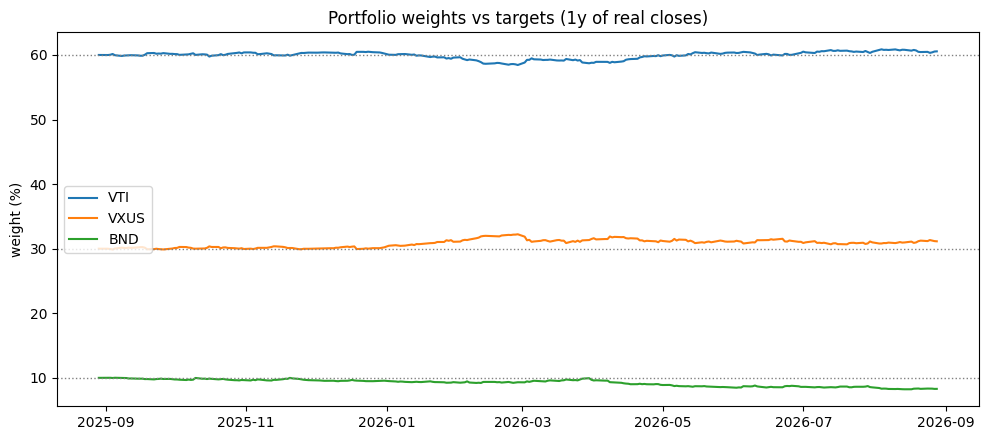

In [15]:
weights_df = pd.DataFrame(weights, index=wide.index, columns=TICKERS)

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, ticker in enumerate(TICKERS):
    ax.plot(weights_df.index, weights_df[ticker] * 100, label=ticker)
    ax.axhline(targets[i] * 100, linestyle=':', linewidth=1, color='grey')

ax.set_title(f'Portfolio weights vs targets ({PERIOD} of real closes)')
ax.set_ylabel('weight (%)')
ax.legend(loc='center left')
fig.tight_layout()
plt.show()

### Sources, parameters and validations

| | |
|---|---|
| Source | yfinance daily closes for VTI, VXUS, BND |
| Parameters | `period='1y'`, `interval='1d'`, `auto_adjust=False` |
| Secrets | `.env` (`DATA_DIR_RAW`, `DATA_DIR_PROCESSED`, `ALPHAVANTAGE_API_KEY`); never committed |
| Output | `data/raw/api_yfinance_VTI-VXUS-BND_<YYYYMMDD-HHMM>.csv` |
| Validation | required columns · dtypes · all tickers present · no NAs · no duplicate (date, ticker) · all prices positive · row counts per ticker |

**Assumptions and risks**

- **Raw close, not adjusted** — dividends and splits are not reflected. Fine for
  weight drift over a one-year window; wrong for computing total return.
- **Prices only.** Weights ignore accrued dividends and any cash sleeve.
- **The model portfolio, not a client account.** No deposits or withdrawals, so
  drift here is a pure price effect. A real account will differ.
- **Vendor dependence.** yfinance is an unofficial wrapper around a public
  endpoint and can break without notice. The shape check on the returned
  columns is deliberate, not defensive noise.
- **Re-running produces a new file** rather than overwriting, which is what
  makes an earlier pull reproducible — at the cost of a growing `data/raw/`.

**Next stage (05):** save a processed table to `data/processed/` in Parquet,
add `write_df` / `read_df` utilities, and append a Data Storage section to the
project README.

---

## Stage 05 — Data Storage

The daily report is a **derived** table: every value in it is recomputed from
`data/raw/` by the code above. So it belongs in `data/processed/`, and it is
saved as **Parquet** rather than CSV — the frame carries a datetime index and
a categorical flag, and CSV would return both as text.

`write_df` and `read_df` now live in `src/utils.py`, so the pipeline and the
homework share one definition rather than two copies that drift apart.

In [16]:
from src.utils import write_df, read_df

# The processed table: one row per (date, fund), with drift and flag.
processed = (weights_df
             .reset_index()
             .melt(id_vars='date', var_name='fund', value_name='current_weight'))
processed['target_weight'] = processed['fund'].map(TARGET_WEIGHTS)
processed['drift_pp'] = drift_pp(processed['current_weight'], processed['target_weight'])
processed['flag'] = flag_drift(processed['drift_pp'])

print(processed.shape)
processed.head()

(753, 6)


,date,fund,current_weight,target_weight,drift_pp,flag
0,2025-08-29,VTI,0.600000,0.6,0.000000,green
1,2025-09-02,VTI,0.599919,0.6,-0.008121,green
2,2025-09-03,VTI,0.600358,0.6,0.035780,green
3,2025-09-04,VTI,0.601512,0.6,0.151162,green
4,2025-09-05,VTI,0.599604,0.6,-0.039599,green


In [17]:
proc_path = write_df(processed, PROC / f"weights_drift_{ts()}.parquet")
print('saved', proc_path)

saved data/processed/weights_drift_20260828-1720.parquet


In [18]:
# Verify the round trip rather than assuming it.
back = read_df(proc_path)
checks = {
    'shape_equal': processed.shape == back.shape,
    'date_is_datetime': pd.api.types.is_datetime64_any_dtype(back['date']),
    'drift_is_numeric': pd.api.types.is_numeric_dtype(back['drift_pp']),
    'values_match': bool(np.allclose(processed['drift_pp'], back['drift_pp'])),
    'flags_match': bool((processed['flag'] == back['flag']).all()),
}
for key, value in checks.items():
    print(f"{key:<20} {value}")
assert all(checks.values()), 'the round trip lost something'

shape_equal          True
date_is_datetime     True
drift_is_numeric     True
values_match         True
flags_match          True


In [19]:
# How often would each flag level have fired over the window?
print(processed['flag'].value_counts(normalize=True).round(4).to_string())
print()
print('worst drift seen per fund (pp):')
print(processed.groupby('fund')['drift_pp'].apply(lambda s: s.abs().max()).round(2).to_string())

flag
green    1.0

worst drift seen per fund (pp):
fund
BND     1.77
VTI     1.55
VXUS    2.23


### What the flag counts say

Over this window the report is **green essentially all of the time** — the 5pp
red threshold from the framing document never fires, and the worst absolute
drift on any fund stays well inside it.

That is a finding, not a bug. A monitor whose alarm never sounds gets ignored
exactly as fast as one that cries wolf, and Dana stops opening the file either
way. **Stage 07's sensitivity analysis is where this gets tested properly** —
how much would the threshold have to move before it fires at a useful rate, and
is that threshold still defensible as a risk policy?

Recorded here rather than acted on, because changing a policy threshold to make
your own output look busier is precisely the decision that needs a documented
justification.

**Next stage (06):** `src/cleaning.py`, applied to this table before it is
saved.